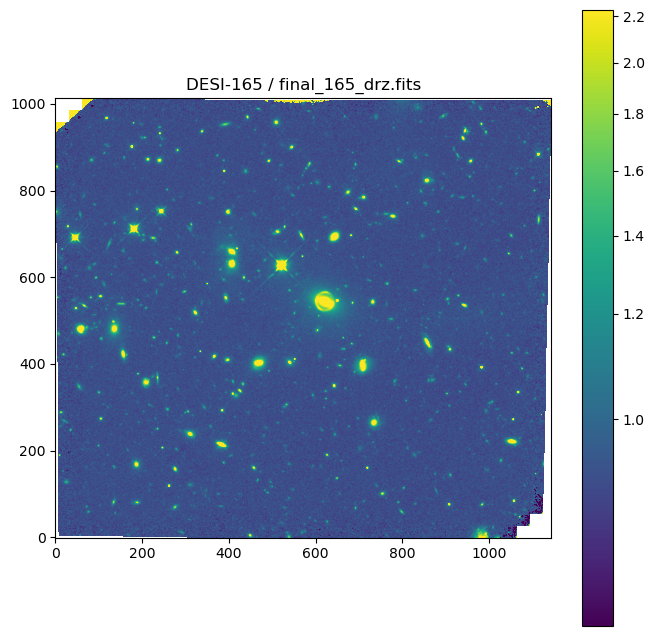

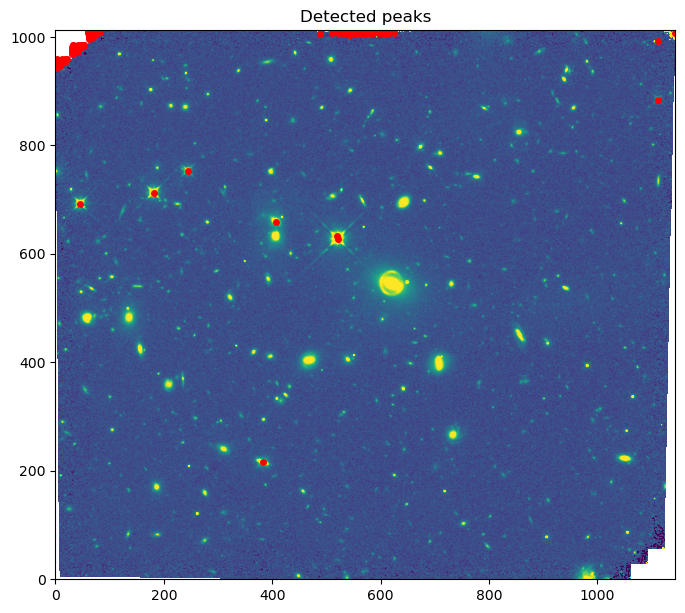

 x    y   peak_value
---- ---- ----------
 521  627  2744.4248
  69 1010  2044.7745
1112  992  1541.7006
 182  712  701.94617
  46  692   534.8319
 244  752  365.93292
 596 1007  232.25325
 606 1009   206.0857
  61 1002  194.34084
   1  948  187.96974
 ...  ...        ...
 614 1005   54.46145
 512 1010  54.243156
 543 1003   54.13181
 551 1008  54.103634
 614 1009  53.943882
1112  883  53.191235
 511 1007  52.090603
 522 1008  50.501144
1143 1007   50.28121
  81 1009  50.242043
  82 1009  50.242043
Length = 153 rows


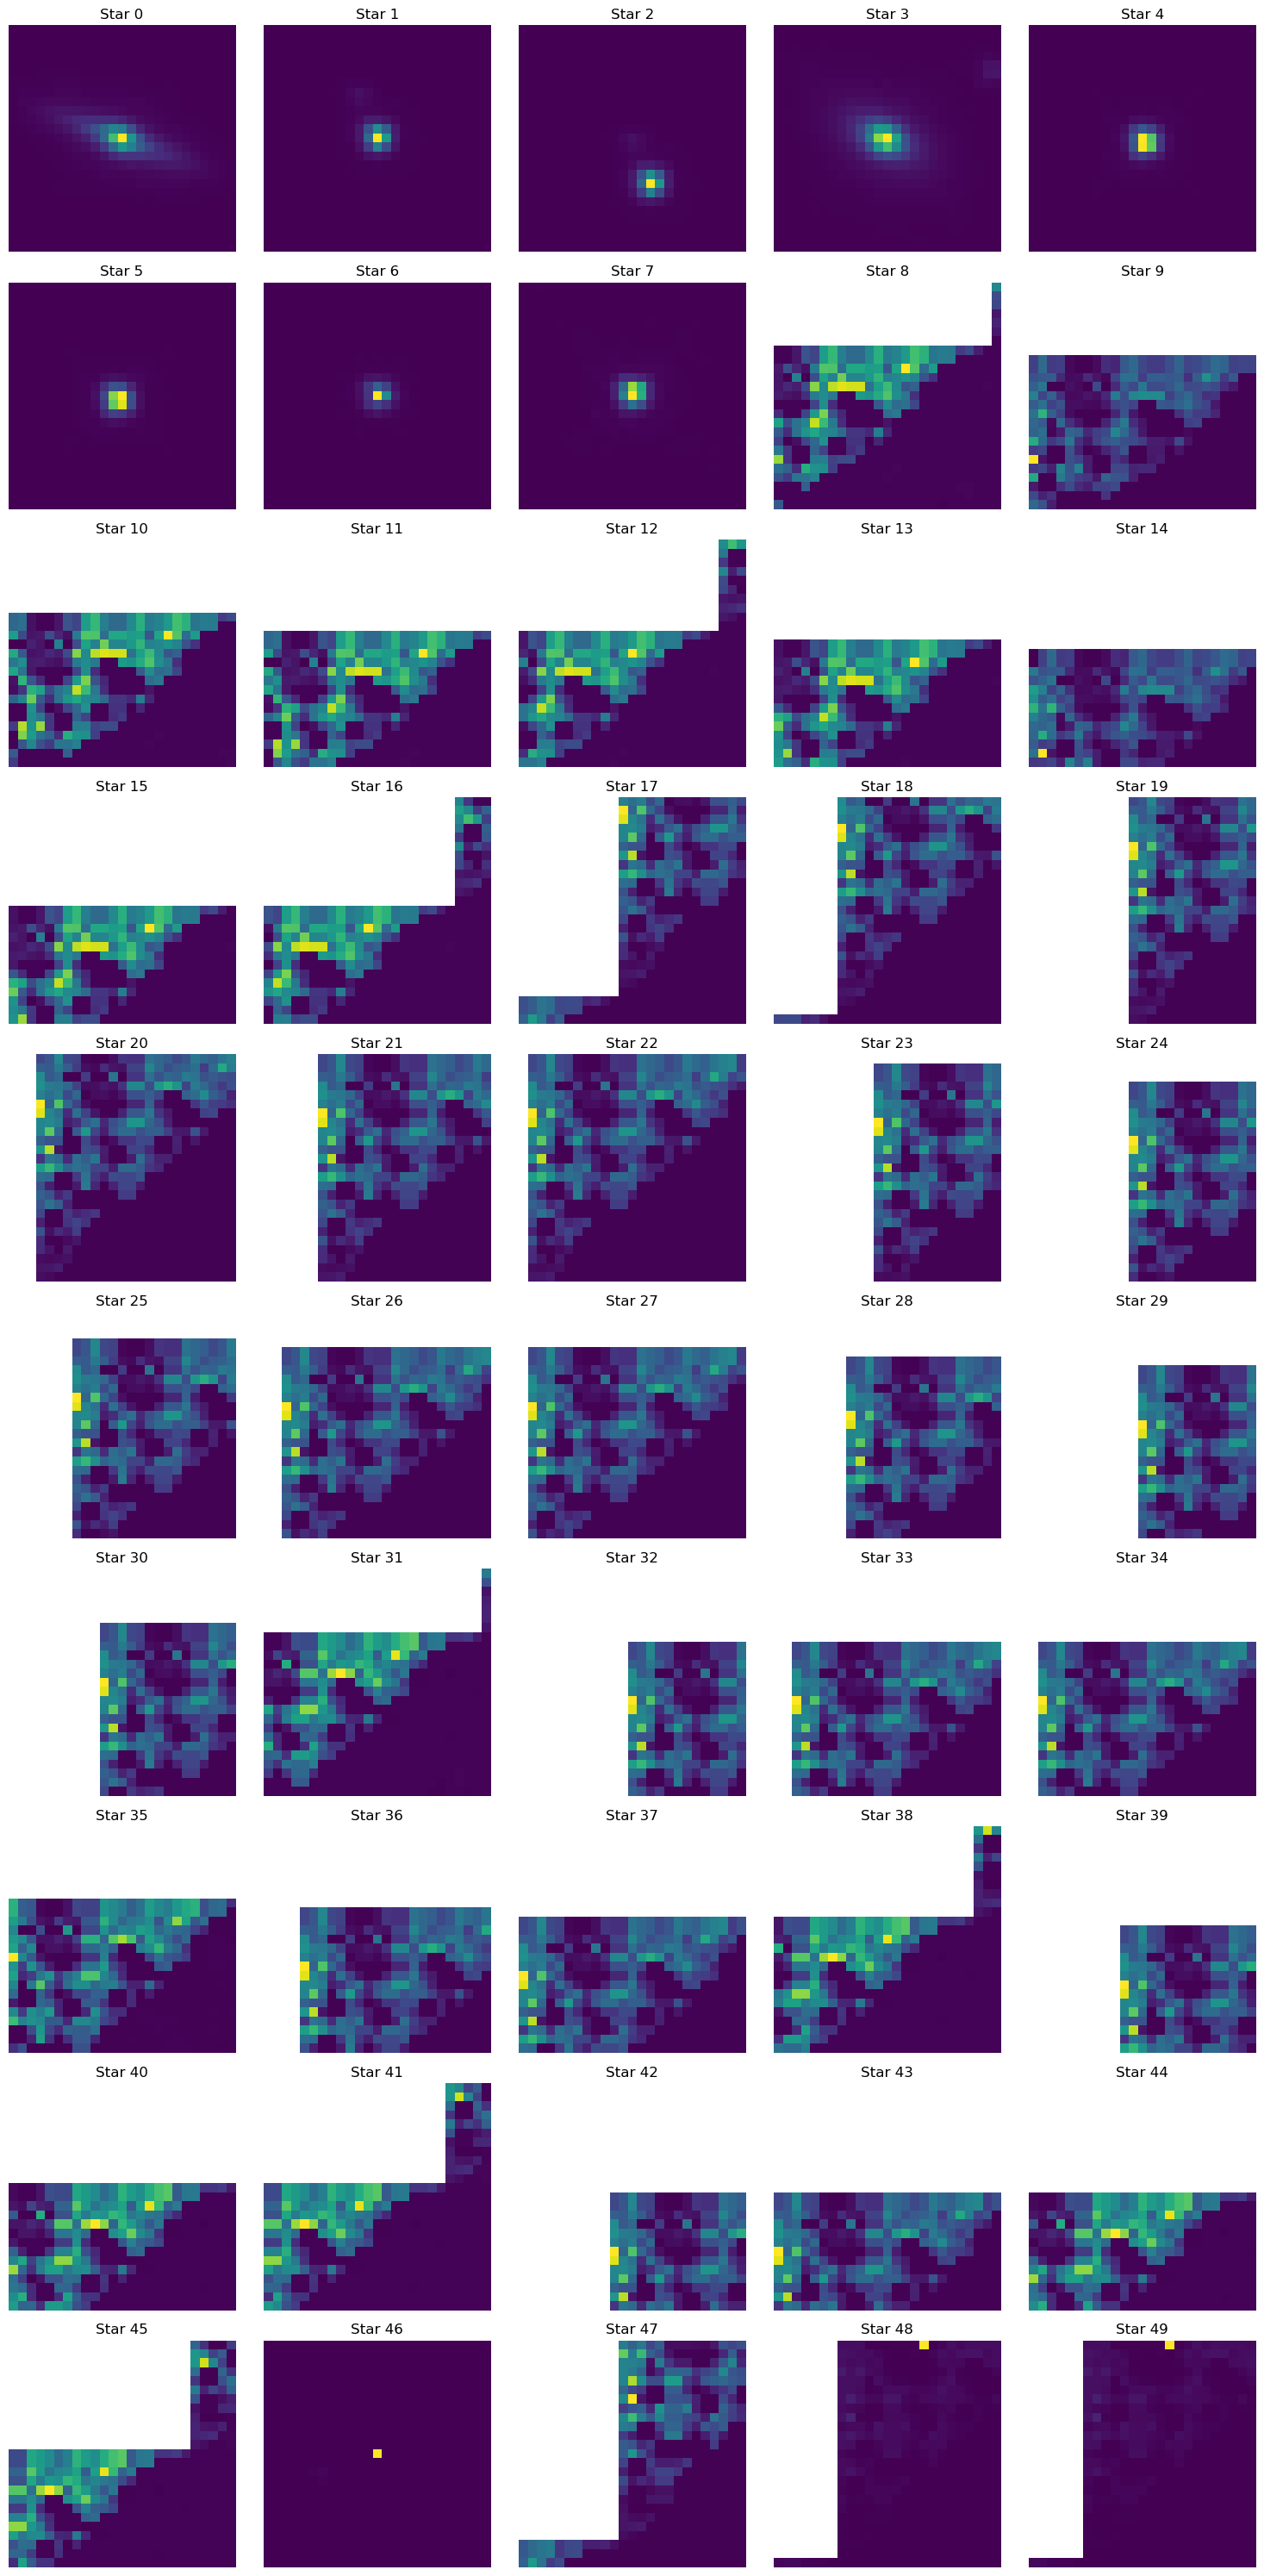

EPSFBuilder (1 maxiters):   0%|          | 0/1 [00:00<?, ?it/s]

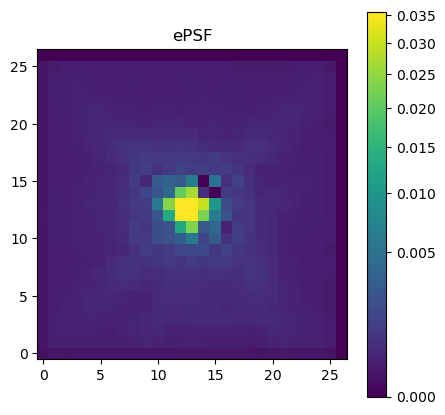

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.nddata import NDData
from astropy.visualization import simple_norm
from photutils.detection import find_peaks
from photutils.psf import EPSFBuilder, extract_stars
from photutils.psf import IntegratedGaussianPRF
from photutils.aperture import CircularAperture
from astropy.table import Table
from astropy.modeling import models, fitting

f = fits.open('desi_165_drz.fits')
imR = f[1].data
f.close()
imR[imR < 0] = 0
plt.figure(figsize=(8,8))
norm = simple_norm(imR.data, 'sqrt', percent=99.)
plt.imshow(imR, origin='lower', norm=norm, cmap='viridis')
plt.title('DESI-165 / final_165_drz.fits')
plt.colorbar()
plt.show()

# find peaks in brightness
threshold = 50
peaks_tbl = find_peaks(imR, threshold=threshold)
# print(peaks_tbl)

# show detected stars
plt.figure(figsize=(8,8))
plt.imshow(imR, origin='lower', cmap='viridis', norm=norm)
plt.title('Detected peaks')
plt.plot(peaks_tbl['x_peak'], peaks_tbl['y_peak'], 'ro', markersize=4)
plt.show()

catalog = Table()
catalog['x'] = peaks_tbl['x_peak']
catalog['y'] = peaks_tbl['y_peak']
stars = extract_stars(NDData(imR), catalog, size=25)
catalog['peak_value'] = peaks_tbl['peak_value']
catalog.sort('peak_value', reverse=True)
print(catalog)

n_stars = len(stars)
n_cols = 5
n_rows = np.ceil(n_stars // n_cols)
fig, axes = plt.subplots(int(n_rows), int(n_cols), figsize=(n_cols*3, n_rows*3))
for i, star in enumerate(stars):
    row = i // n_cols
    col = i % n_cols
    if row < len(axes) and col < len(axes[0]):
        ax = axes[row, col]
        im = ax.imshow(star.data, origin='lower', cmap='viridis')
        ax.set_title(f'Star {i}')
        ax.axis('off')
plt.tight_layout()
plt.show()

# extract stars i want
stars_to_use = stars[:7]

# build epsf
builder = EPSFBuilder(maxiters=1, oversampling=1)
epsf, fitted_stars = builder.build_epsf(stars_to_use)
psf_array = epsf.data.astype(np.float32)
np.save('psf.npy', psf_array)

# visualize epsf
plt.figure(figsize=(5,5))
plt.imshow(epsf.data, origin='lower', norm=simple_norm(epsf.data, 'sqrt', percent=99.), cmap='viridis')
plt.colorbar()
plt.title('ePSF')
plt.show()

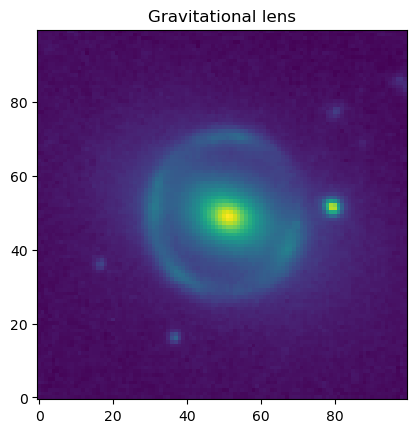

In [28]:
from astropy.nddata import Cutout2D

ny, nx = imR.shape
center = (620, 545)
cutout_size = (100, 100)
cutout = Cutout2D(imR, position=center, size=cutout_size)
imL = np.nan_to_num(cutout.data, nan=0.0, posinf=0.0, neginf=0.0)
ny, nx = imL.shape
py, px = np.mgrid[:ny, :nx]
plt.imshow(imL, origin='lower', cmap='viridis', norm='log')
plt.title("Gravitational lens")
plt.show()

np.save('imL.npy', imL) # 100x100

In [1]:
import numpy as np
from astropy.io import fits
from photutils.background import Background2D, MedianBackground

# load image
img = fits.open("desi_165_drz.fits")[1].data

# estimate background
bkg = Background2D(
    img,
    box_size=50,          # size of background boxes (pixels)
    filter_size=3,        # smooth background map
    bkg_estimator=MedianBackground()
)

background = bkg.background
background_rms = bkg.background_rms

print("Global background RMS:", np.median(background_rms))


Global background RMS: 0.026169747


In [2]:
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np

hdu = fits.open("desi_165_drz.fits")
wcs = WCS(hdu[1].header)

# pixel scale in degrees/pixel
pixscale_deg = np.mean(np.abs(wcs.pixel_scale_matrix.diagonal()))

# convert to arcsec/pixel
delta_pix = pixscale_deg * 3600

print("delta_pix =", delta_pix, "arcsec/pixel")


delta_pix = 0.08815583493104795 arcsec/pixel


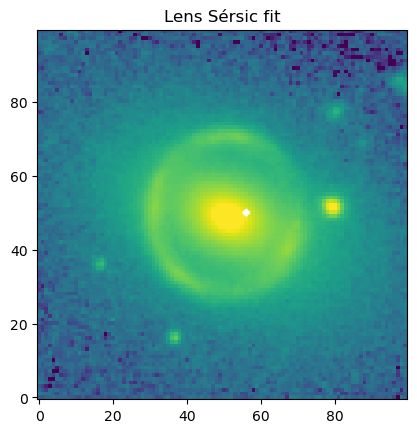

Fitted lens Sérsic parameters:
Amplitude: 1e-05
R_e: 100.0
n: 8.0
Center: (55.99900064147238, 49.99673219213115)
Ellipticity: 0.0
Theta: -0.3876264447826507


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.modeling import models, fitting
from astropy.visualization import simple_norm

# Load cutout
imL = np.clip(np.nan_to_num(np.load('imL.npy'), nan=0.0, posinf=0.0, neginf=0.0), a_min=1e-6, a_max=None)
ny, nx = imL.shape
y, x = np.mgrid[:ny, :nx]

# --- Normalize for better fitting ---
norm = simple_norm(imL, 'log', percent=99.)

total_flux = np.sum(imL)
y_cm, x_cm = np.unravel_index(np.argmax(imL), imL.shape) # Start at the brightest pixel

sersic_init = models.Sersic2D(
    amplitude = np.max(imL), 
    x_0 = x_cm, 
    y_0 = y_cm,
    n = 1.5, # Start with a "flatter" profile (Disk-like) as it's more stable
    r_eff = 5.0, # Start small and let it grow
    ellip = 0.2
)

# --- Apply "Priors" (Bounds) ---
# Amplitude must be positive
sersic_init.amplitude.min = 1e-5

# r_eff must be positive and usually shouldn't exceed the cutout size
sersic_init.r_eff.min = 0.5
sersic_init.r_eff.max = nx 

# Sérsic index n: 0.5 (Gaussian/disk) to 8.0 (extreme elliptical)
# Most fitters crash if n > 10
sersic_init.n.min = 0.5
sersic_init.n.max = 8.0

# Ellipticity must be between 0 and 1
sersic_init.ellip.min = 0.0
sersic_init.ellip.max = 0.9

# Center should stay within the cutout
sersic_init.x_0.min = 0
sersic_init.x_0.max = nx
sersic_init.y_0.min = 0
sersic_init.y_0.max = ny


# --- Fitter ---
fitter = fitting.LevMarLSQFitter()
sersic_fit = fitter(sersic_init, x, y, imL)

# --- Display fit ---
fit_model = sersic_fit(x, y)
plt.imshow(imL, origin='lower', cmap='viridis', norm=norm)
plt.contour(fit_model, colors='white', levels=5)
plt.title("Lens Sérsic fit")
plt.show()

# --- Print fitted parameters ---
print("Fitted lens Sérsic parameters:")
print(f"Amplitude: {sersic_fit.amplitude.value}")
print(f"R_e: {sersic_fit.r_eff.value}")
print(f"n: {sersic_fit.n.value}")
print(f"Center: ({sersic_fit.x_0.value}, {sersic_fit.y_0.value})")
print(f"Ellipticity: {sersic_fit.ellip.value}")
print(f"Theta: {sersic_fit.theta.value}")
